# Functional ANOVA Example: Temperature Profiles Over Time

This notebook demonstrates how to perform a **one-way Functional ANOVA (F-ANOVA)** using the `functionalANOVA` package on temperature trajectories observed over time.

---

## Dataset Description

The dataset contains temperature measurements collected over a common time interval \([0, 1]\) seconds.

- `t` — time vector (seconds)
- `group1_*` — temperature trajectories for Group A
- `group2_*` — temperature trajectories for Group B
- `group3_*` — temperature trajectories for Group C

Each column represents a single temperature realization (functional sample), and each row corresponds to a discretized time point.

Thus, the dataset is structured as:

- **Rows:** Time points  
- **Columns:** Functional temperature samples  

---

## Objective

The goal of this analysis is to determine whether the **mean temperature profiles differ across groups over time**.

Specifically, we:

1. Load and inspect the functional dataset  
2. Extract temperature trajectories by group  
3. Format the data for the `functionalANOVA` class  
4. Perform:
   - One-way functional ANOVA (family-wise and pairwise testing)
   - Bootstrap-based inference  
5. Visualize:
   - Group mean temperature curves  
   - Individual realizations  
   - Covariance structure  

---

## Functional Data Representation

The `functionalANOVA` class expects input as a list of NumPy arrays:


In [19]:
import numpy as np
import pandas as pd
import os
from functionalANOVA.fanova import functionalANOVA

# Import Data
df = pd.read_csv("../Data/gait_data.csv");

In [20]:
# Basic overview
display(df.head())
print("Shape:", df.shape)

# Identify group columns
group1_cols = [col for col in df.columns if col.startswith("group1")]
group2_cols = [col for col in df.columns if col.startswith("group2")]
group3_cols = [col for col in df.columns if col.startswith("group3")]

print("\nFunctional sample counts:")
print(f"  Group 1: {len(group1_cols)} samples")
print(f"  Group 2: {len(group2_cols)} samples")
print(f"  Group 3: {len(group3_cols)} samples")

# Convert to NumPy arrays (time_points × samples)
group1 = df[group1_cols].to_numpy()
group2 = df[group2_cols].to_numpy()
group3 = df[group3_cols].to_numpy()

print("\nArray shapes (time_points × samples):")
print(f"  Group 1: {group1.shape}")
print(f"  Group 2: {group2.shape}")
print(f"  Group 3: {group3.shape}")

# Final structure expected by functionalANOVA
group_arrays = [group1, group2, group3]

,t,group1,group1.1,group1.2,group1.3,group1.4,group1.5,group1.6,group1.7,group1.8,...,group3.3,group3.4,group3.5,group3.6,group3.7,group3.8,group3.9,group3.10,group3.11,group3.12
0,0.025,37,47,46,37,20,57,46,46,46,...,46,54,52,32,46,46,48,44,55,48
1,0.075,36,46,44,36,18,48,38,46,42,...,47,48,44,28,41,44,42,41,56,50
2,0.125,33,42,39,27,11,44,33,43,37,...,44,44,44,26,38,40,42,38,51,47
3,0.175,29,34,34,20,8,35,25,40,34,...,37,37,33,22,31,35,35,32,46,42
4,0.225,23,27,33,15,7,31,18,36,31,...,29,30,28,19,25,31,30,24,41,37


Shape: (20, 40)

Functional sample counts:
  Group 1: 13 samples
  Group 2: 13 samples
  Group 3: 13 samples

Array shapes (time_points × samples):
  Group 1: (20, 13)
  Group 2: (20, 13)
  Group 3: (20, 13)


In [21]:
# Extract time vector
time = df["t"].to_numpy()
# Bounds on time
bounds = (-np.inf, np.inf)

In [22]:
myANOVA = functionalANOVA(data_list=group_arrays, d_grid=time, grid_bounds=bounds,
                          group_labels=['Group A', 'Group B', 'Group C'],
                          domain_label='Time', domain_units='Seconds',
                          response_label='Temperature', response_units='Celcius')

C:\Users\351718\Documents\F-ANOVA_PYTHON\F-ANOVA-py\functionalANOVA\fanova.py:170: UserWarning: Functional data has a resolution of 20 elements. It is recommended to have a resolution of at least 1000 elements for the convergence of the F-ANOVA p-values
  warnings.warn(f'Functional data has a resolution of {self.n_domain_points} elements. It is recommended to have a resolution of at least 1000 elements for the convergence of the F-ANOVA p-values')


## Mean Function Hypothesis Testing

The `functionalANOVA` framework supports two types of inference on group mean functions:

---

### Family-Wise (Global) Testing

The family-wise test evaluates whether **any group mean function differs from the others over the time domain**.

The null hypothesis is:

$$
H_0: \mu_1(t) = \mu_2(t) = \cdots = \mu_G(t)
\quad \text{for all } t
$$

This is a global test of equality across all groups simultaneously.

- If the null is rejected, at least one group mean differs.
- It does not specify which groups differ.
- It controls inference at the overall group level.

This test answers:

> “Is there *any* difference among the mean temperature trajectories?”

---

### Pairwise Testing

Pairwise testing compares groups **two at a time**.

For groups \(i\) and \(j\), the hypothesis is:

$$
H_0: \mu_i(t) = \mu_j(t)
\quad \text{for all } t
$$
This allows identification of **which specific group pairs differ**.

Pairwise testing answers:

> “Which groups have different temperature profiles?”

---

### Practical Interpretation

- **Family-wise testing** is appropriate for detecting the presence of any group differences.
- **Pairwise testing** is used for detailed follow-up comparisons.

Both approaches operate on functional mean curves rather than scalar summaries.

In [23]:
myANOVA.oneway(hypothesis='family')

Calculating, Family-wise, Bootstrap F-type test: 100%|██████████| 10000/10000 [00:00<00:00, 10731.45it/s]


One-Way homoskedastic F-ANOVA Data Summary:

Confidence Level = 95.000 %
Number of Observations Total = 39
Number of Points in Domain = 20
Number of Groups = 3
Domain Range = [0.025, 0.975]
Domain Subset = [-inf, inf]
Group Observation Size: [13, 13, 13]
Group Labels: [Group A, Group B, Group C]


  Family-Wise Method Test-Statistic P-Value                         Verdict  \
0           L2-Simul      2637.1282  0.2051  Fail to Reject Null Hypothesis   
1           L2-Naive      2637.1282  0.2107  Fail to Reject Null Hypothesis   
2     L2-BiasReduced      2637.1282  0.1958  Fail to Reject Null Hypothesis   
3       L2-Bootstrap      2637.1282  0.1805  Fail to Reject Null Hypothesis   
4            F-Simul         1.4670  0.2102  Fail to Reject Null Hypothesis   
5            F-Naive         1.4670  0.2227  Fail to Reject Null Hypothesis   
6      F-BiasReduced         1.4670  0.2199  Fail to Reject Null Hypothesis   
7        F-Bootstrap         1.4670  0.2028  Fail to Reject Null Hyp

In [24]:
myANOVA.oneway(hypothesis='pairwise')

Calculating, Pair-wise (Group A & Group B), Bootstrap L2 test: 100%|██████████| 10000/10000 [00:00<00:00, 12156.51it/s]
Calculating, Pair-wise (Group A & Group C), Bootstrap L2 test: 100%|██████████| 10000/10000 [00:00<00:00, 12148.65it/s]
Calculating, Pair-wise (Group B & Group C), Bootstrap L2 test: 100%|██████████| 10000/10000 [00:00<00:00, 12306.01it/s]
Calculating, Pair-wise (Group A & Group B), Bootstrap F-type test: 100%|██████████| 10000/10000 [00:00<00:00, 11628.70it/s]
Calculating, Pair-wise (Group A & Group C), Bootstrap F-type test: 100%|██████████| 10000/10000 [00:00<00:00, 11657.15it/s]
Calculating, Pair-wise (Group B & Group C), Bootstrap F-type test: 100%|██████████| 10000/10000 [00:00<00:00, 11663.66it/s]


One-Way homoskedastic F-ANOVA Data Summary:

Confidence Level = 95.000 %
Number of Observations Total = 39
Number of Points in Domain = 20
Number of Groups = 3
Domain Range = [0.025, 0.975]
Domain Subset = [-inf, inf]
Group Observation Size: [13, 13, 13]
Group Labels: [Group A, Group B, Group C]


          Hypothesis L2-Simul L2-Naive L2-BiasReduced L2-Bootstrap F-Simul  \
0  Group A & Group B   0.5207   0.5226         0.5216       0.3925  0.5396   
1  Group A & Group C   0.0662   0.0678         0.0600       0.0722  0.0722   
2  Group B & Group C   0.3210   0.3503         0.3434       0.3140  0.3366   

  F-Naive F-BiasReduced F-Bootstrap  
0  0.5256        0.5337      0.5513  
1  0.0747        0.0714      0.0852  
2  0.3557        0.3585      0.3558  


## Covariance Assumptions: Homoscedastic vs Heteroscedastic Testing

In addition to testing differences in mean functions, the `functionalANOVA` framework allows different assumptions about covariance structure.

---

### Homoscedastic Model (`oneway`)

The standard one-way functional ANOVA assumes that all groups share a common covariance function:

$$
\Sigma_1(t,s) = \Sigma_2(t,s) = \cdots = \Sigma_G(t,s)
$$

Under this assumption:

- A **pooled covariance estimate** is computed.
- Variability is assumed equal across groups.
- The resulting test statistic mirrors classical ANOVA assumptions.

This approach is appropriate when groups exhibit similar variability patterns over time.

---

### Heteroscedastic (Behrens–Fisher) Model (`oneway_bf`)

The Behrens–Fisher functional approach relaxes the equal covariance assumption:

$$
\Sigma_i(t,s) \neq \Sigma_j(t,s)
$$

Each group has its own covariance estimate.

Under this framework:

- Covariance functions are estimated separately by group.
- No pooled covariance operator is used.
- The test statistic accounts for group-specific variability.

This method is appropriate when:

- Groups show visibly different variance structure,
- Variability differs in magnitude,
- Or covariance shape differs across time.

---

### Summary of Available Procedures

| Mean Test Type | Covariance Assumption | Method |
|---------------|-----------------------|--------|
| Family-wise   | Equal covariance      | `oneway(hypothesis='family')` |
| Pairwise      | Equal covariance      | `oneway(hypothesis='pairwise')` |
| Family-wise   | Unequal covariance    | `oneway_bf(hypothesis='family')` |
| Pairwise      | Unequal covariance    | `oneway_bf(hypothesis='pairwise')` |

---

These options allow flexible functional inference depending on whether covariance homogeneity is assumed or relaxed.

In [25]:
myANOVA.oneway_bf(hypothesis='family')

Calculating, Family-wise, Bootstrap F-type test: 100%|██████████| 10000/10000 [00:00<00:00, 12644.36it/s]


One-Way heteroskedastic F-ANOVA Data Summary:

Confidence Level = 95.000 %
Number of Observations Total = 39
Number of Points in Domain = 20
Number of Groups = 3
Domain Range = [0.025, 0.975]
Domain Subset = [-inf, inf]
Group Observation Size: [13, 13, 13]
Group Labels: [Group A, Group B, Group C]


  Family-Wise Method Test-Statistic P-Value                         Verdict
0           L2-Simul      2637.1282  0.2022  Fail to Reject Null Hypothesis
1           L2-Naive      2637.1282  0.2149  Fail to Reject Null Hypothesis
2     L2-BiasReduced      2637.1282  0.1900  Fail to Reject Null Hypothesis
3       L2-Bootstrap      2637.1282  0.1648  Fail to Reject Null Hypothesis
4            F-Simul         1.4670  0.2116  Fail to Reject Null Hypothesis
5            F-Naive         1.4670  0.2150  Fail to Reject Null Hypothesis
6      F-BiasReduced         1.4670  0.2031  Fail to Reject Null Hypothesis
7        F-Bootstrap         1.4670  0.2051  Fail to Reject Null Hypothesis


In [26]:
myANOVA.oneway_bf(hypothesis='pairwise')

Calculating, Pair-wise (Group A & Group B), Bootstrap L2 test: 100%|██████████| 10000/10000 [00:00<00:00, 21564.37it/s]
Calculating, Pair-wise (Group A & Group C), Bootstrap L2 test: 100%|██████████| 10000/10000 [00:00<00:00, 21022.89it/s]
Calculating, Pair-wise (Group B & Group C), Bootstrap L2 test: 100%|██████████| 10000/10000 [00:00<00:00, 21885.92it/s]
Calculating, Pair-wise (Group A & Group B), Bootstrap F-type test: 100%|██████████| 10000/10000 [00:00<00:00, 14778.78it/s]
Calculating, Pair-wise (Group A & Group C), Bootstrap F-type test: 100%|██████████| 10000/10000 [00:00<00:00, 14490.67it/s]
Calculating, Pair-wise (Group B & Group C), Bootstrap F-type test: 100%|██████████| 10000/10000 [00:00<00:00, 14036.44it/s]


One-Way heteroskedastic F-ANOVA Data Summary:

Confidence Level = 95.000 %
Number of Observations Total = 39
Number of Points in Domain = 20
Number of Groups = 3
Domain Range = [0.025, 0.975]
Domain Subset = [-inf, inf]
Group Observation Size: [13, 13, 13]
Group Labels: [Group A, Group B, Group C]


          Hypothesis L2-Simul L2-Naive L2-BiasReduced L2-Bootstrap F-Simul  \
0  Group A & Group B   0.4415   0.4512         0.4543       0.3902  0.4509   
1  Group A & Group C   0.0856   0.0917         0.0735       0.0708  0.0930   
2  Group B & Group C   0.3441   0.3737         0.3691       0.3071  0.3614   

  F-Naive F-BiasReduced F-Bootstrap  
0  0.4512        0.4691      0.4384  
1  0.0918        0.0824      0.1022  
2  0.3737        0.3851      0.3507  


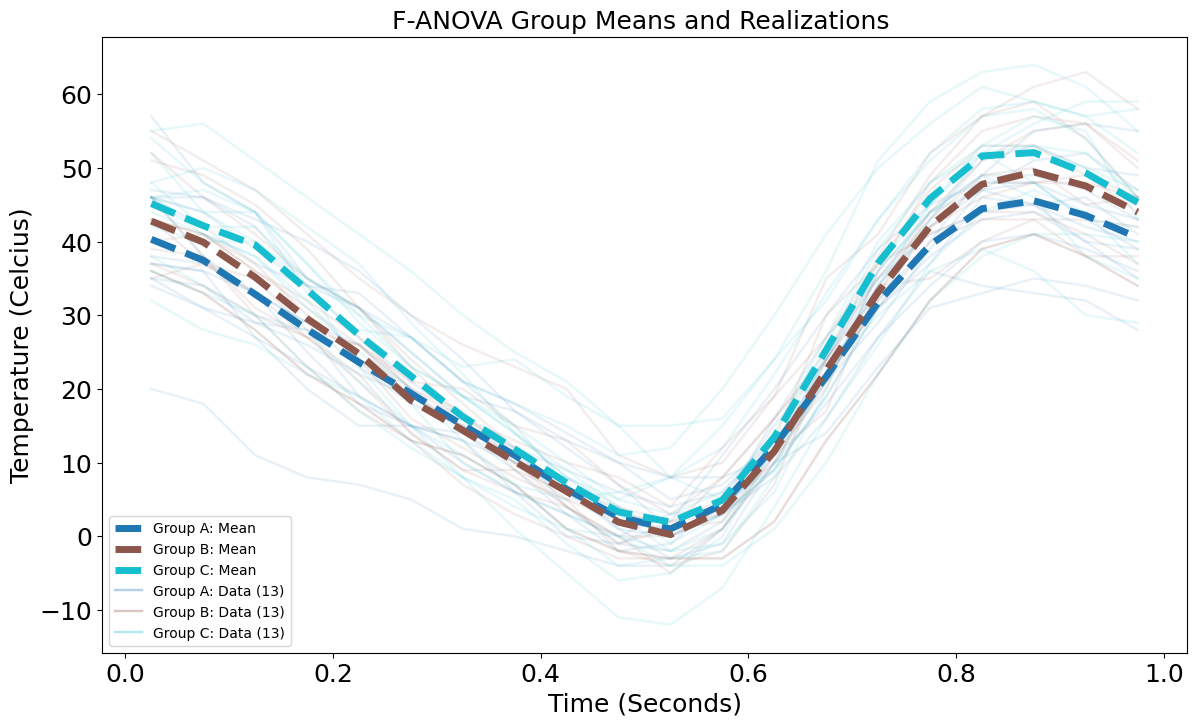

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'F-ANOVA Group Means and Realizations '}, xlabel='Time (Seconds)', ylabel='Temperature (Celcius)'>)

In [27]:
myANOVA.plot_means()

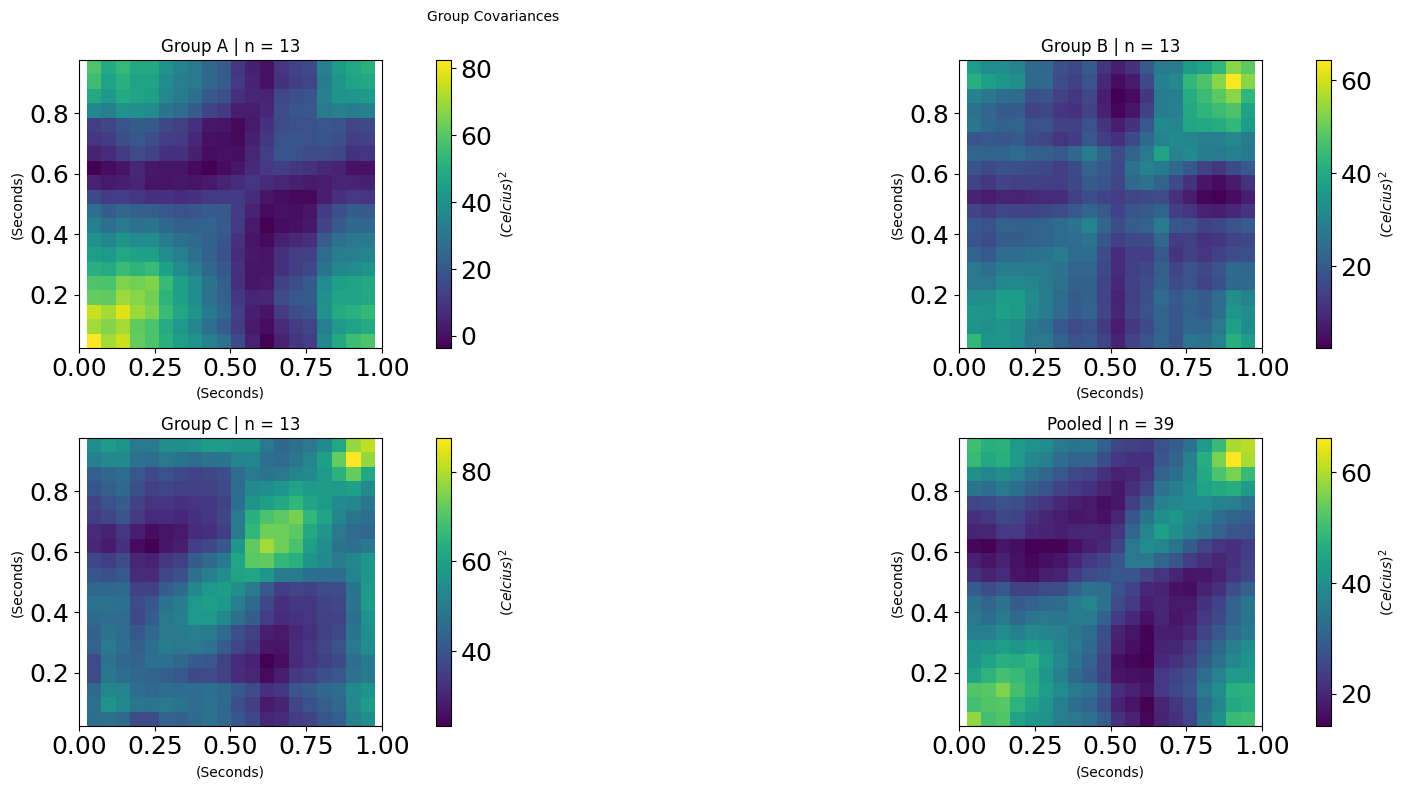

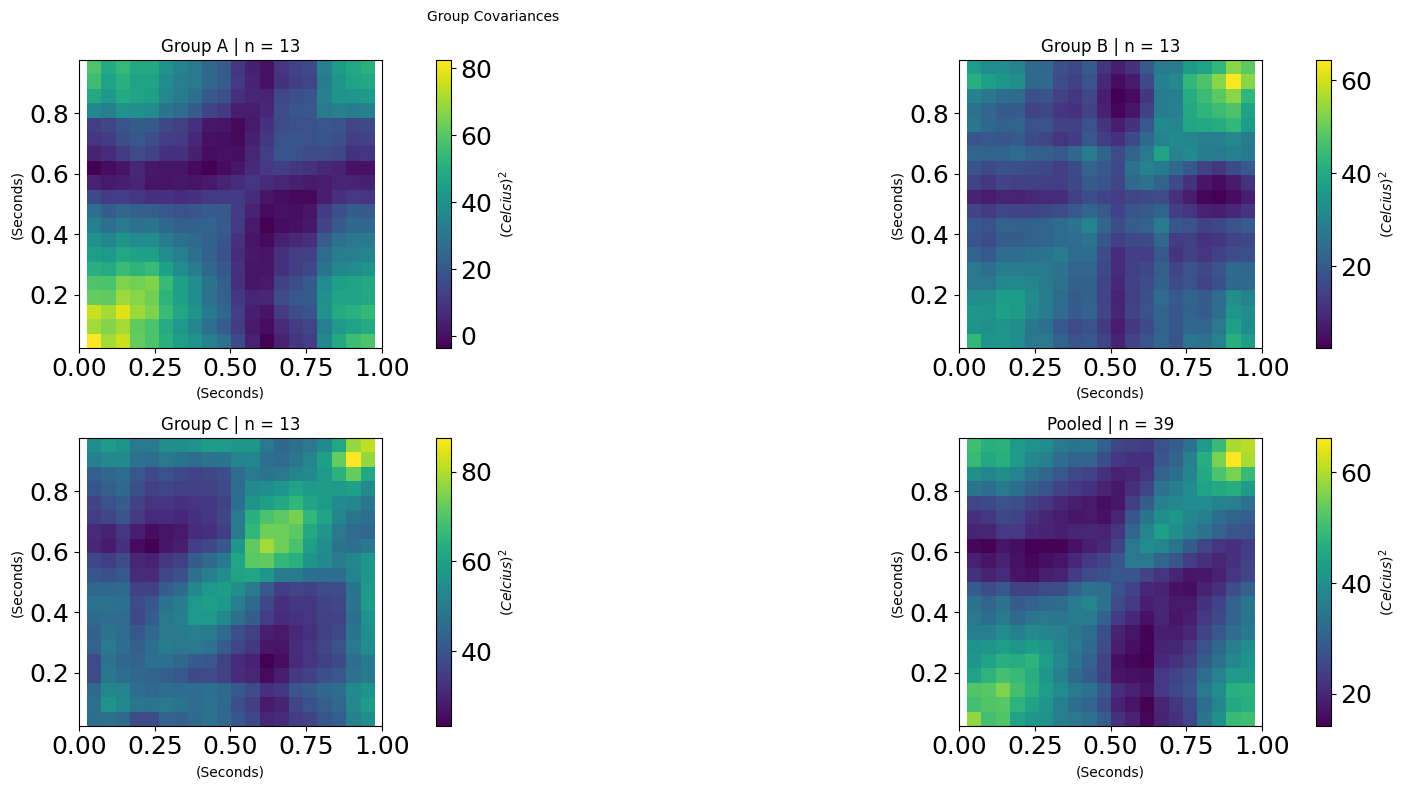

In [28]:
myANOVA.plot_covariances()